# XResNet1d-101 on PTB-XL

Multi-label ECG classification using a 1-D XResNet-101.

## Sections
1. Setup & Data Loading
2. Model Construction
3. Training
4. Evaluation


## 0. Install dependencies

In [1]:
import sys, os
# Add project root to path so local packages are importable
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import sys
print(sys.executable)


c:\Users\inaki\anaconda3\envs\ptbxl\python.exe


## 1. Load PTB-XL data

In [2]:
import torch
import importlib
from pathlib import Path
import utils.data_loader

# Force reload local modules during pipeline runs
importlib.reload(utils.data_loader)
from utils.data_loader import load_ptbxl

# Global paths and tracking parameters
PATH = Path("../ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/")
SAMPLING_RATE = 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if not PATH.exists():
    print(f"ERROR: Dataset not found at {PATH.absolute()}")

# Define automated multi-task targets and summary container
TASKS_TO_RUN = ['superclass', 'subclass', 'scp-statement']
ecg_summary_metrics = {}

# Start of the automated multi-task processing loop
for current_task in TASKS_TO_RUN:
    print("\n" + "="*80)
    print(f"STARTING PIPELINE EXECUTION FOR BASELINE ECG COMPONENT: [{current_task.upper()}]")
    print("="*80)
    
    # Load dynamic ECG arrays and corresponding class configurations per task 
    X_train, X_val, X_test, y_train, y_val, y_test, classes, _ = load_ptbxl(
        PATH, SAMPLING_RATE, task=current_task
    )
    num_classes = len(classes)
    
    print(f"Classes for {current_task} ({num_classes}):", classes)
    print("X_train shape   :", X_train.shape)
    print("X_val   shape   :", X_val.shape)
    print("X_test  shape   :", X_test.shape)


STARTING PIPELINE EXECUTION FOR BASELINE ECG COMPONENT: [SUPERCLASS]
Classes for superclass (5): ['CD', 'HYP', 'MI', 'NORM', 'STTC']
X_train shape   : (17418, 1000, 12)
X_val   shape   : (2183, 1000, 12)
X_test  shape   : (2198, 1000, 12)

STARTING PIPELINE EXECUTION FOR BASELINE ECG COMPONENT: [SUBCLASS]
  [Loader] Sliced subclass down to top 10 categories: ['AMI', 'IMI', 'IRBBB', 'ISCA', 'ISC_', 'LAFB/LPFB', 'LVH', 'NORM', 'STTC', '_AVB']
Classes for subclass (10): ['AMI', 'IMI', 'IRBBB', 'ISCA', 'ISC_', 'LAFB/LPFB', 'LVH', 'NORM', 'STTC', '_AVB']
X_train shape   : (17418, 1000, 12)
X_val   shape   : (2183, 1000, 12)
X_test  shape   : (2198, 1000, 12)

STARTING PIPELINE EXECUTION FOR BASELINE ECG COMPONENT: [SCP-STATEMENT]
  [Loader] Sliced scp-statement down to top 10 categories: ['1AVB', 'ASMI', 'IMI', 'IRBBB', 'ISC_', 'IVCD', 'LAFB', 'LVH', 'NDT', 'NORM']
Classes for scp-statement (10): ['1AVB', 'ASMI', 'IMI', 'IRBBB', 'ISC_', 'IVCD', 'LAFB', 'LVH', 'NDT', 'NORM']
X_train shape  

## 2. Build the XResNet1d-101 model & 3. Train & 4. Evaluation


RUNNING MODEL PIPELINE FOR TARGET: [SUPERCLASS]

Building dataloaders and model structure for task variant: [superclass]
Model successfully built for [superclass] on device cuda. Head features mapped to 5 outputs.
Epoch   1: train=0.3542  val=0.3312
Epoch   2: train=0.3114  val=0.3265
Epoch   3: train=0.2946  val=0.3030
Epoch   4: train=0.2839  val=0.3304
Epoch   5: train=0.2760  val=0.2995
Epoch   6: train=0.2677  val=0.3027
Epoch   7: train=0.2617  val=0.2923
Epoch   8: train=0.2571  val=0.3139
Epoch   9: train=0.2523  val=0.2905
Epoch  10: train=0.2480  val=0.2849
Epoch  11: train=0.2450  val=0.2837
Epoch  12: train=0.2426  val=0.2913
Epoch  13: train=0.2387  val=0.2833
Epoch  14: train=0.2361  val=0.2832
Epoch  15: train=0.2325  val=0.2851
Epoch  16: train=0.2297  val=0.3102
Epoch  17: train=0.2281  val=0.2798
Epoch  18: train=0.2239  val=0.3096
Epoch  19: train=0.2203  val=0.3197
Epoch  20: train=0.2178  val=0.3037
Epoch  21: train=0.2001  val=0.2867
Epoch  22: train=0.1933  val=

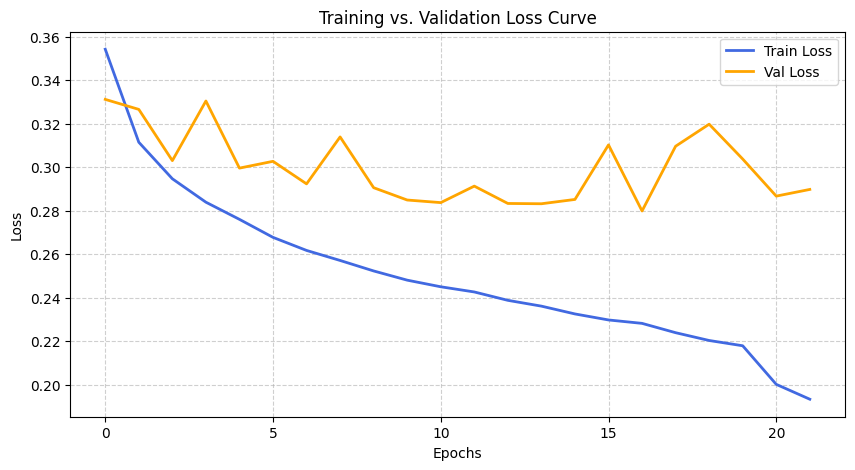

==> Target [SUPERCLASS] fully optimized and checkpointed.


Evaluating performance benchmarks for task target: [SUPERCLASS]


C:\Users\inaki\AppData\Local\Temp\ipykernel_42148\565891320.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"../outputs/best_ecg_model


=== BASELINE ECG MODEL RESULTS: [SUPERCLASS] ===
Accuracy: 0.6124
F1: 0.7224
Precision (PPV): 0.7882
Sensitivity (Recall): 0.6838
Specificity: 0.9301
MCC: 0.6524
AUC: 0.9202

[SUPERCLASS] Per-class AUC: {'CD': 0.9096331166369735, 'HYP': 0.8913869787395118, 'MI': 0.9246646072374228, 'NORM': 0.9462038753725915, 'STTC': 0.9291933200338325}
[SUPERCLASS] Macro AUC: 0.9202


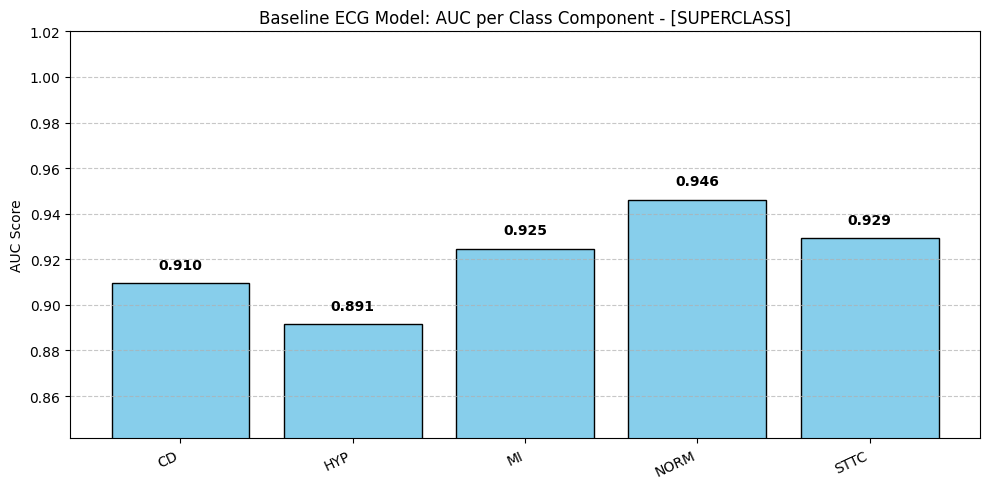

Ground truth: [0. 0. 0. 1. 0.]
Predictions : [0.08605649 0.01316137 0.21112323 0.7887854  0.00887807]


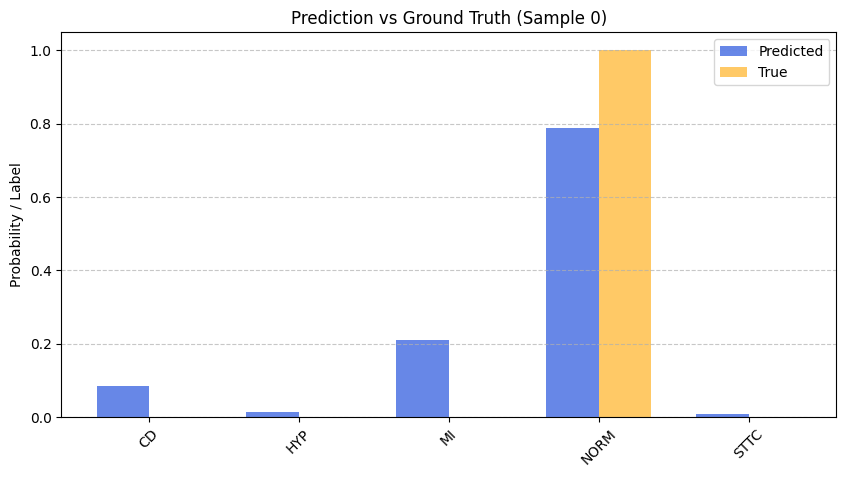

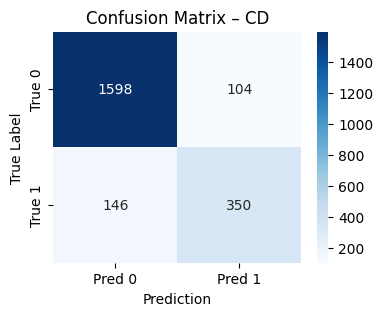

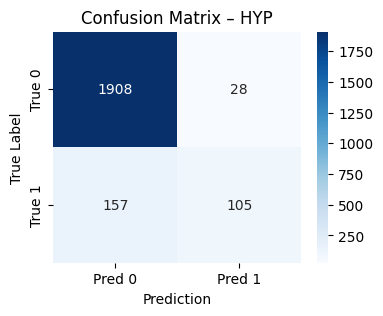

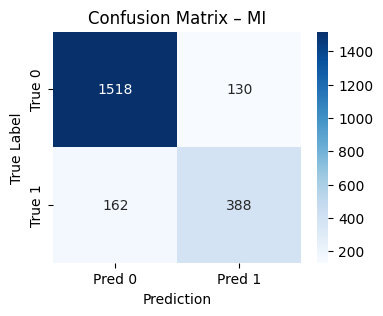

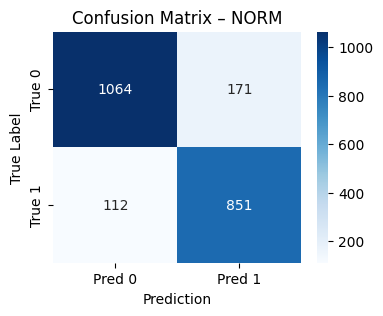

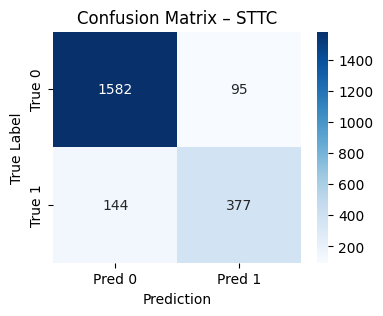


RUNNING MODEL PIPELINE FOR TARGET: [SUBCLASS]
  [Loader] Sliced subclass down to top 10 categories: ['AMI', 'IMI', 'IRBBB', 'ISCA', 'ISC_', 'LAFB/LPFB', 'LVH', 'NORM', 'STTC', '_AVB']

Building dataloaders and model structure for task variant: [subclass]
Model successfully built for [subclass] on device cuda. Head features mapped to 10 outputs.
Epoch   1: train=0.2137  val=0.1994
Epoch   2: train=0.1808  val=0.1985
Epoch   3: train=0.1710  val=0.1987
Epoch   4: train=0.1655  val=0.1793
Epoch   5: train=0.1604  val=0.1721
Epoch   6: train=0.1580  val=0.1697
Epoch   7: train=0.1536  val=0.1731
Epoch   8: train=0.1503  val=0.1807
Epoch   9: train=0.1483  val=0.1687
Epoch  10: train=0.1457  val=0.1692
Epoch  11: train=0.1434  val=0.1638
Epoch  12: train=0.1426  val=0.1626
Epoch  13: train=0.1391  val=0.1638
Epoch  14: train=0.1385  val=0.1659
Epoch  15: train=0.1372  val=0.1684
Epoch  16: train=0.1258  val=0.1654
Epoch  17: train=0.1232  val=0.1652
Early stopping triggered.


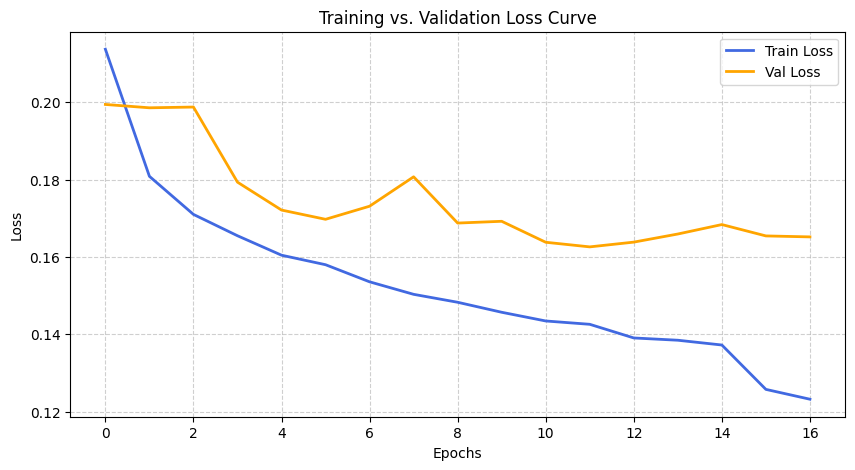

==> Target [SUBCLASS] fully optimized and checkpointed.


Evaluating performance benchmarks for task target: [SUBCLASS]


C:\Users\inaki\AppData\Local\Temp\ipykernel_42148\565891320.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"../outputs/best_ecg_model


=== BASELINE ECG MODEL RESULTS: [SUBCLASS] ===
Accuracy: 0.5760
F1: 0.5566
Precision (PPV): 0.6900
Sensitivity (Recall): 0.4973
Specificity: 0.9659
MCC: 0.5341
AUC: 0.9456

[SUBCLASS] Per-class AUC: {'AMI': 0.9542794566734375, 'IMI': 0.9308061070548873, 'IRBBB': 0.9643071154636351, 'ISCA': 0.9194799887620361, 'ISC_': 0.9657118055555556, 'LAFB/LPFB': 0.9684422566622671, 'LVH': 0.9473286290322581, 'NORM': 0.9435266815493082, 'STTC': 0.9026995112521429, '_AVB': 0.9593342247222094}
[SUBCLASS] Macro AUC: 0.9456


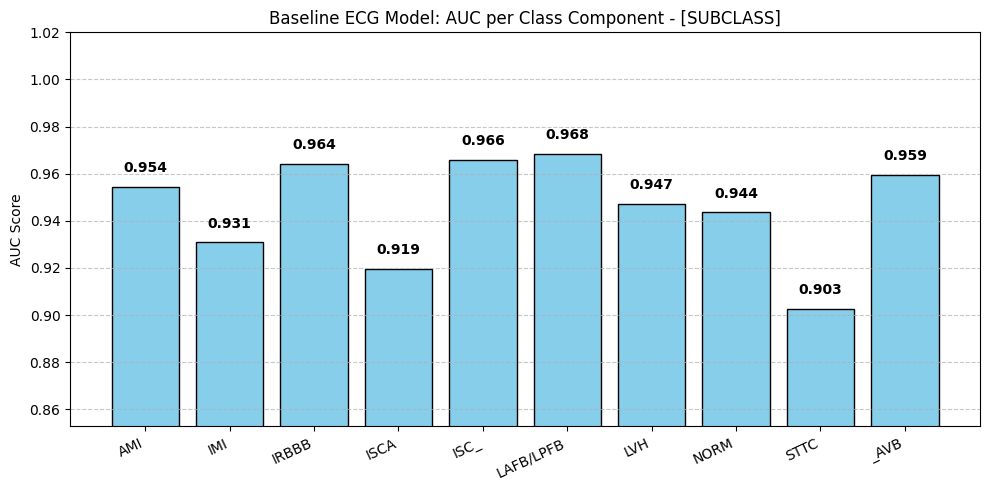

Ground truth: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Predictions : [1.19539257e-02 5.65802213e-03 1.05766580e-03 3.17414670e-04
 1.00348094e-04 4.63008089e-03 2.25172518e-03 9.24032688e-01
 6.71850098e-03 2.77051888e-03]


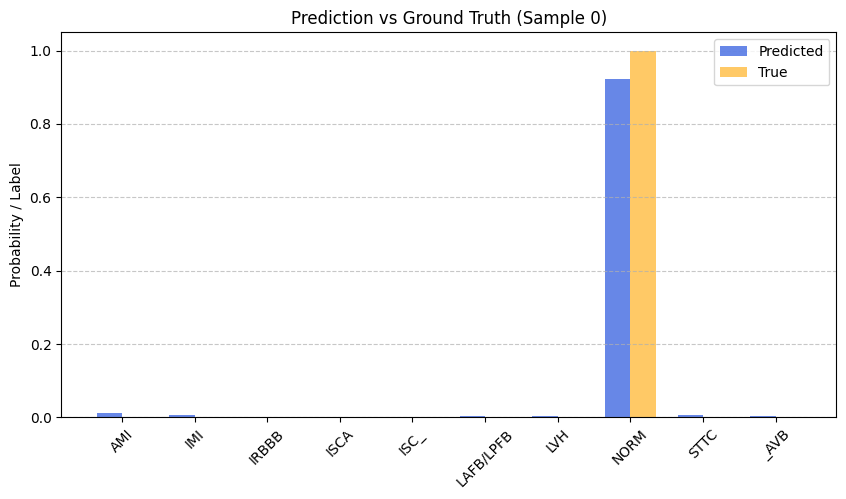

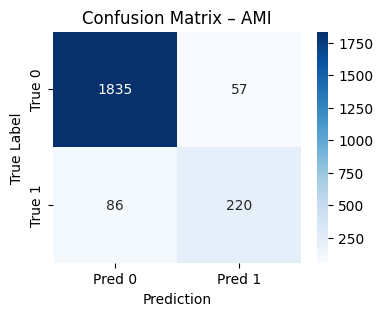

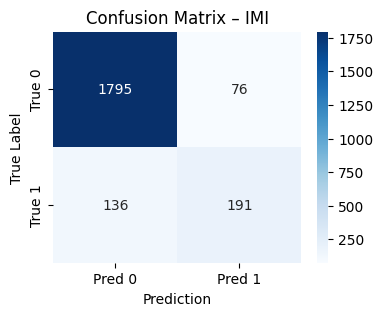

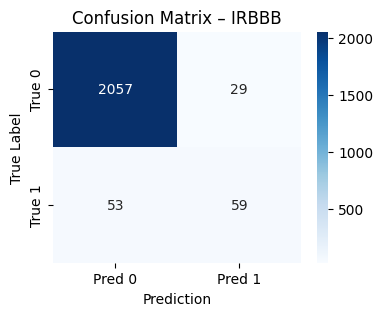

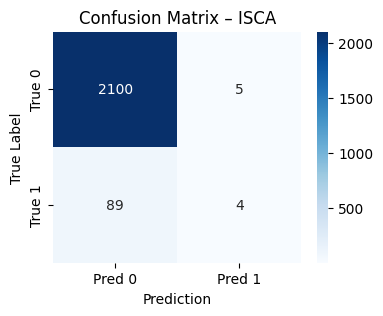

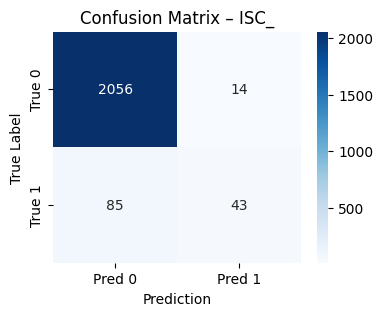

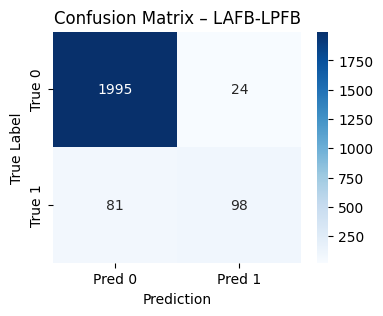

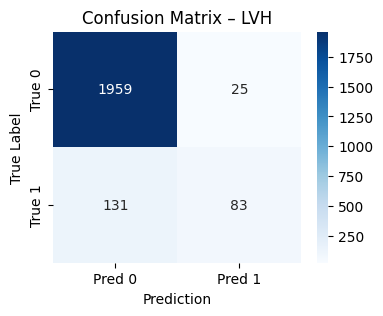

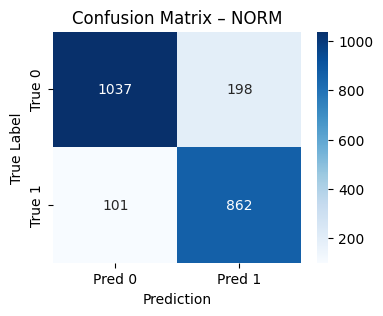

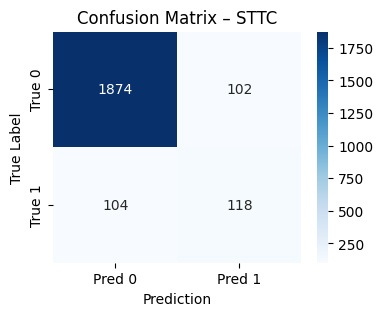

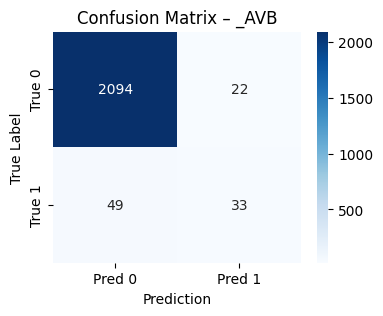


RUNNING MODEL PIPELINE FOR TARGET: [SCP-STATEMENT]
  [Loader] Sliced scp-statement down to top 10 categories: ['1AVB', 'ASMI', 'IMI', 'IRBBB', 'ISC_', 'IVCD', 'LAFB', 'LVH', 'NDT', 'NORM']

Building dataloaders and model structure for task variant: [scp-statement]
Model successfully built for [scp-statement] on device cuda. Head features mapped to 10 outputs.
Epoch   1: train=0.1995  val=0.1831
Epoch   2: train=0.1701  val=0.1736
Epoch   3: train=0.1616  val=0.1806
Epoch   4: train=0.1572  val=0.1841
Epoch   5: train=0.1516  val=0.1638
Epoch   6: train=0.1485  val=0.1666
Epoch   7: train=0.1451  val=0.1596
Epoch   8: train=0.1419  val=0.1618
Epoch   9: train=0.1394  val=0.1641
Epoch  10: train=0.1378  val=0.1571
Epoch  11: train=0.1354  val=0.1657
Epoch  12: train=0.1345  val=0.1625
Epoch  13: train=0.1324  val=0.1551
Epoch  14: train=0.1304  val=0.1550
Epoch  15: train=0.1297  val=0.1575
Epoch  16: train=0.1278  val=0.1558
Epoch  17: train=0.1264  val=0.1599
Epoch  18: train=0.1156  

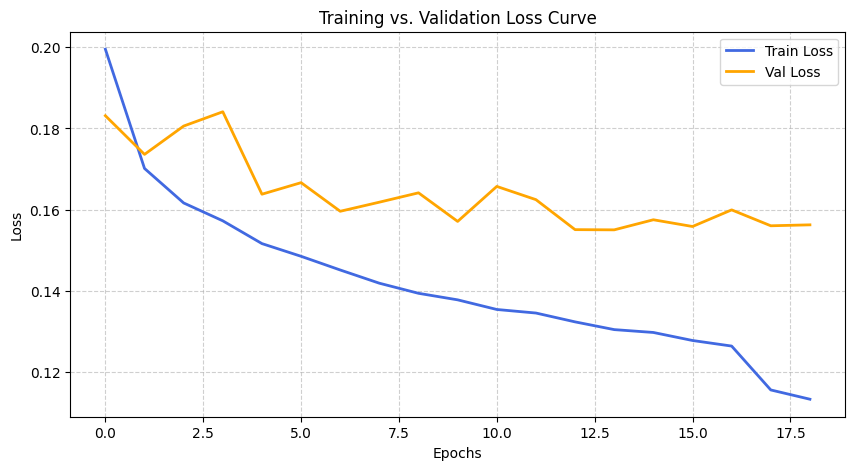

==> Target [SCP-STATEMENT] fully optimized and checkpointed.


Evaluating performance benchmarks for task target: [SCP-STATEMENT]


C:\Users\inaki\AppData\Local\Temp\ipykernel_42148\565891320.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"../outputs/best_ecg_model


=== BASELINE ECG MODEL RESULTS: [SCP-STATEMENT] ===
Accuracy: 0.5974
F1: 0.5433
Precision (PPV): 0.6503
Sensitivity (Recall): 0.4802
Specificity: 0.9664
MCC: 0.5189
AUC: 0.9280

[SCP-STATEMENT] Per-class AUC: {'1AVB': 0.9740324131874959, 'ASMI': 0.9681554302226401, 'IMI': 0.9224189597286147, 'IRBBB': 0.9614650390357485, 'ISC_': 0.9613262379227053, 'IVCD': 0.7151032550582134, 'LAFB': 0.9730559800140678, 'LVH': 0.94031692794694, 'NDT': 0.9224555206698064, 'NORM': 0.942082981236941}
[SCP-STATEMENT] Macro AUC: 0.9280


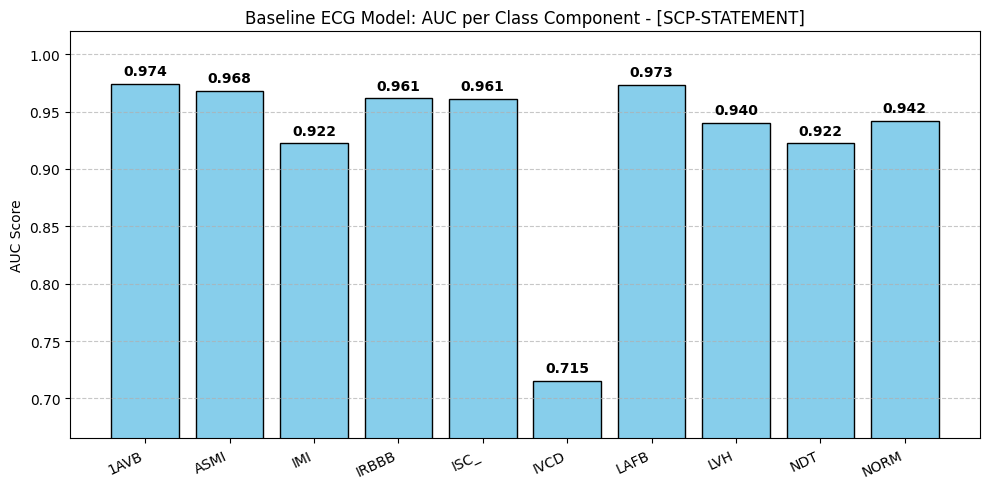

Ground truth: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Predictions : [1.8814909e-03 2.0134891e-03 1.2272003e-02 1.5723783e-03 8.7133965e-05
 1.1612650e-02 6.0626987e-04 1.5500779e-03 2.8313152e-03 9.5344454e-01]


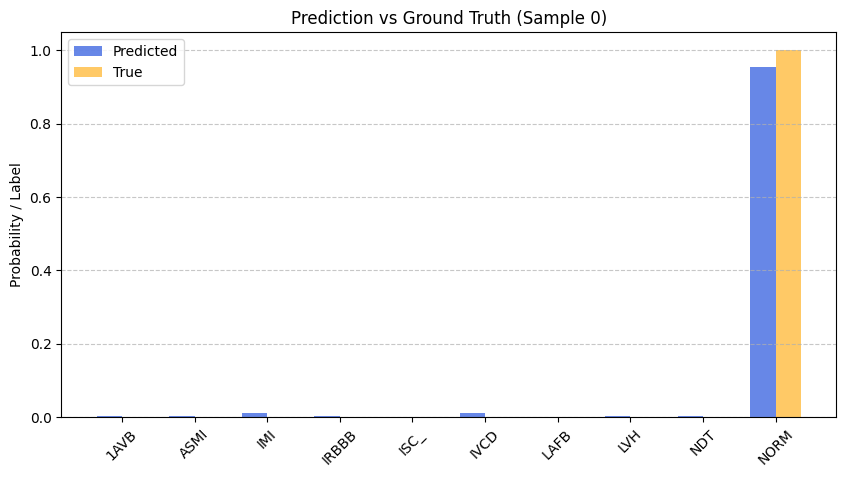

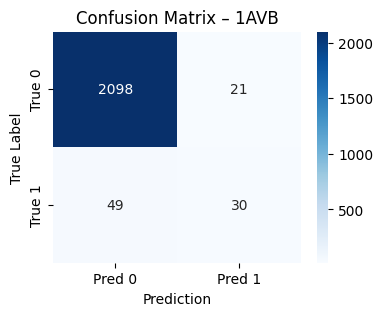

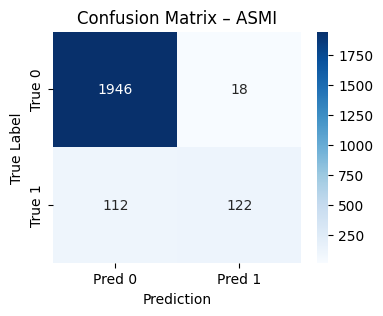

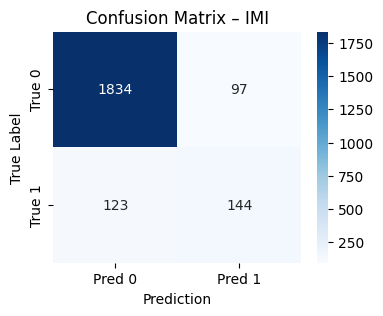

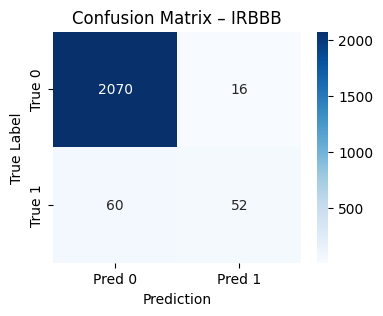

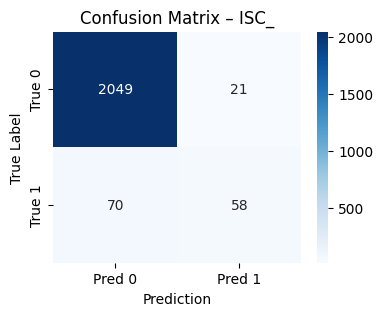

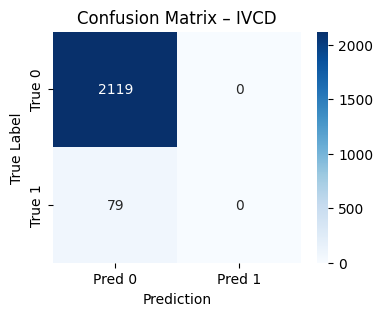

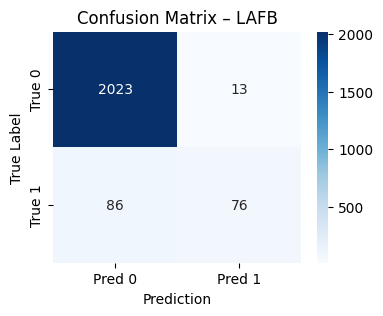

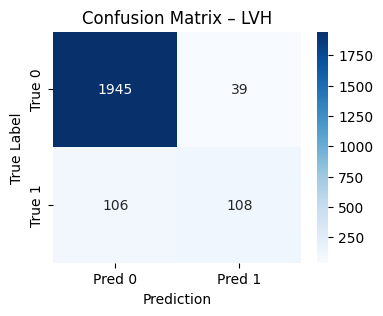

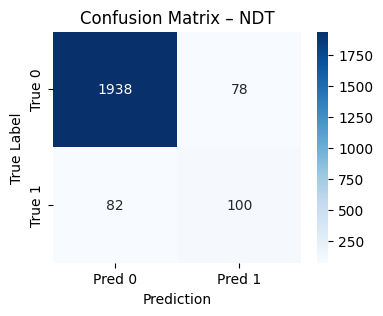

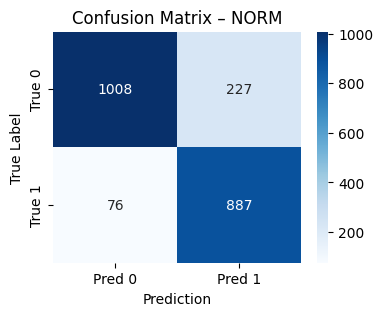


ALL BASELINE ECG PIPELINE MODEL EXECUTIONS COMPLETED SUCCESSFULLY
Task Target Category | Test Accuracy   | Macro F1-Score  | Macro ROC-AUC  
---------------------------------------------------------------------------
superclass           |          0.6124 |          0.7224 |          0.9202
subclass             |          0.5760 |          0.5566 |          0.9456
scp-statement        |          0.5974 |          0.5433 |          0.9280


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import importlib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ── FORCED METRICS AND DATA LOADER CACHE RELOADS ─────────────────────
import utils.data_loader
import utils.metrics
importlib.reload(utils.data_loader)
importlib.reload(utils.metrics)  

from utils.data_loader import load_ptbxl, PTBXL_Dataset
from utils.trainer     import train, get_predictions
from utils.metrics     import (
    plot_losses,
    compute_auc_per_class,
    compute_macro_auc,
    plot_auc_bar,
    plot_prediction_vs_truth,
    plot_confusion_matrices,
    compute_all_metrics,
)
from models.xresnet1d import build_xresnet1d101

os.makedirs("../outputs", exist_ok=True)


# Start of the structural training loop
for current_task in TASKS_TO_RUN:
    print("\n" + "="*80)
    print(f"RUNNING MODEL PIPELINE FOR TARGET: [{current_task.upper()}]")
    print("="*80)
    
    # Isolate data arrays dynamically for this task iteration loop step
    X_train, X_val, X_test, y_train, y_val, y_test, classes, _ = load_ptbxl(
        PATH, SAMPLING_RATE, task=current_task
    )
    num_classes = len(classes)


    # =====================================================================
    # ## 2. Build the XResNet1d-101 model
    # =====================================================================
    print(f"\nBuilding dataloaders and model structure for task variant: [{current_task}]")

    # Clean, direct dataloader initialization using the helper function
    from utils.data_loader import build_dataloaders
    train_dl, val_dl, test_dl = build_dataloaders(
        X_train, X_val, X_test, y_train, y_val, y_test, batch_size=32
    )

    # Initialize pure native 1D architecture from models/xresnet1d.py
    model = build_xresnet1d101(
        num_classes=num_classes,
        input_channels=12,
        device=DEVICE
    )
    print(f"Model successfully built for [{current_task}] on device {DEVICE}. Head features mapped to {num_classes} outputs.")
    
    
    # =====================================================================
    # ## 3. Train
    # =====================================================================
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # Run structural training
    train_losses, val_losses = train(
        model=model,
        train_dl=train_dl,
        val_dl=val_dl,
        optimizer=optimizer,
        criterion=criterion,
        num_epochs=50,
        patience=5,
        checkpoint_path=f"../outputs/best_ecg_model_{current_task}.pt",
        device=DEVICE,
    )

    plot_losses(train_losses, val_losses, save_path=f"../outputs/loss_curve_{current_task}.png")
    print(f"==> Target [{current_task.upper()}] fully optimized and checkpointed.\n")

    # =====================================================================
    # ## 4. Evaluation and Performance Logging
    # =====================================================================
    print(f"\nEvaluating performance benchmarks for task target: [{current_task.upper()}]")
    
    # Load raw state_dict natively without wrapper conflicts
    model.load_state_dict(torch.load(f"../outputs/best_ecg_model_{current_task}.pt", map_location=DEVICE))
    model.eval()

    all_preds, all_targets = get_predictions(model, test_dl, device=DEVICE)

    print(f"\n=== BASELINE ECG MODEL RESULTS: [{current_task.upper()}] ===")
    metrics = compute_all_metrics(all_targets, all_preds)

    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    ecg_summary_metrics[current_task] = {
        "Accuracy": metrics.get("Accuracy", 0.0),
        "F1": metrics.get("F1", 0.0),
        "ROC-AUC": metrics.get("AUC", 0.0) 
    }

    auc_scores = compute_auc_per_class(all_targets, all_preds, classes)
    macro_auc  = compute_macro_auc(auc_scores)

    print(f"\n[{current_task.upper()}] Per-class AUC:", auc_scores)
    print(f"[{current_task.upper()}] Macro AUC: {macro_auc:.4f}")

    # A. Generate the task performance visualization plot
    plt.figure(figsize=(10, 5))
    bars = plt.bar(auc_scores.keys(), auc_scores.values(), color='skyblue', edgecolor='black')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

    min_observed_auc = min(auc_scores.values()) if len(auc_scores) > 0 else 0.8
    plt.ylim(max(0.0, min_observed_auc - 0.05), 1.02) 

    plt.title(f'Baseline ECG Model: AUC per Class Component - [{current_task.upper()}]')
    plt.ylabel('AUC Score')
    plt.xticks(rotation=25, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(f"../outputs/auc_bar_{current_task}.png")
    plt.show()

    # B. Single-sample prediction vs truth 
    plot_prediction_vs_truth(
        all_preds, all_targets, classes,
        sample_idx=0,
        save_path=f"../outputs/pred_vs_truth_{current_task}.png",
    )

    # C. Confusion matrices for all classes
    sanitized_classes = [str(cls).replace("/", "-").replace("\\", "-") for cls in classes]
    
    plot_confusion_matrices(
        all_targets, all_preds, sanitized_classes,
        threshold=0.5,
        save_dir=f"../outputs/confusion_matrices_{current_task}",
    )

# ── FINAL SUMMARY REPORT ─────────────────────────────────────────────
print("\n" + "="*80)
print("ALL BASELINE ECG PIPELINE MODEL EXECUTIONS COMPLETED SUCCESSFULLY")
print("="*80)
print(f"{'Task Target Category':20} | {'Test Accuracy':15} | {'Macro F1-Score':15} | {'Macro ROC-AUC':15}")
print("-" * 75)

for task_name, task_metrics in ecg_summary_metrics.items():
    print(f"{task_name:20s} | {task_metrics['Accuracy']:15.4f} | {task_metrics['F1']:15.4f} | {task_metrics['ROC-AUC']:15.4f}")
print("="*75)